In [66]:
A_norm

array([[1. , 0.4, 0. ],
       [0. , 0.4, 1. ],
       [1. , 0. , 0.6]])

In [65]:
import numpy as np
from numpy.linalg import eig

A = np.array([
    [5, 2, 0],
    [1, 3, 6],
    [10, 5, 8]
])

# Min-max normalization by row
A_min = A.min(axis=1, keepdims=True)
A_max = A.max(axis=1, keepdims=True)
A_norm = (A - A_min) / (A_max - A_min)

eigvals, _ = eig(A_norm)
print("정규화 행렬 고유값:\n", eigvals)

정규화 행렬 고유값:
 [1.44906893+0.j         0.27546553+0.60479885j 0.27546553-0.60479885j]


In [18]:
(x[:, np.newaxis, :] - x[np.newaxis, :, :])

(1000, 1000, 2)

In [32]:
eigenvalues, eigenvectors = eigh(P)

In [33]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
lambdas = eigenvalues[1:n_components+1]
psi = eigenvectors[:, 1:n_components+1]
coords = psi * lambdas

NameError: name 'n_components' is not defined

In [48]:
n_components = 2

In [49]:
lambdas = eigenvalues[1:n_components+1]
psi = eigenvectors[:, 1:n_components+1]

In [55]:
z = eigenvalues / np.sum(eigenvalues)

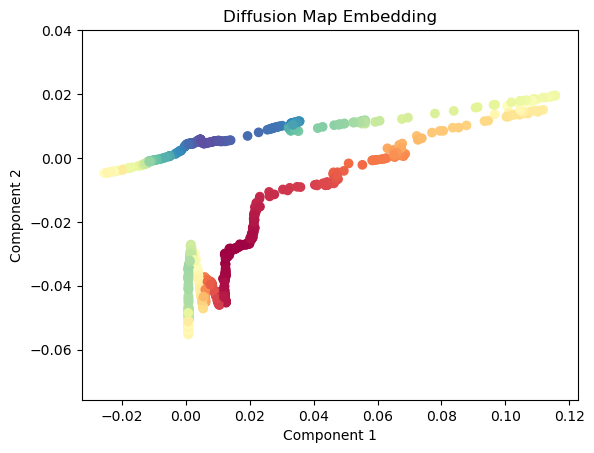

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from scipy.linalg import eigh

# Step 1: 데이터 생성
X, _ = make_swiss_roll(n_samples=1000, noise=0.05)
X = X[:, [0, 2]]  # 2D로 줄여서 시각화 용이

# Step 2: 커널 행렬 생성
def compute_kernel(X, epsilon):
    pairwise_sq_dists = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :])**2, axis=2)
    K = np.exp(-pairwise_sq_dists / epsilon)
    return K

# Step 3: 커널 정규화 (Markov matrix)
def normalize_kernel(K):
    d = np.sum(K, axis=1)
    P = K / d[:, None]
    return P

# Step 4: 고유값 분해
def diffusion_map(P, n_components=5):
    eigenvalues, eigenvectors = eigh(P)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    lambdas = eigenvalues[1:n_components+1]
    psi = eigenvectors[:, 1:n_components+1]
    coords = psi * lambdas
    return coords, lambdas

# 전체 실행
epsilon = 1.0
K = compute_kernel(X, epsilon)
P = normalize_kernel(K)
coords, lambdas = diffusion_map(P)

# 시각화
plt.scatter(coords[:, 0], coords[:, 1], c=X[:, 0], cmap='Spectral')
plt.title('Diffusion Map Embedding')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.axis('equal')
plt.show()

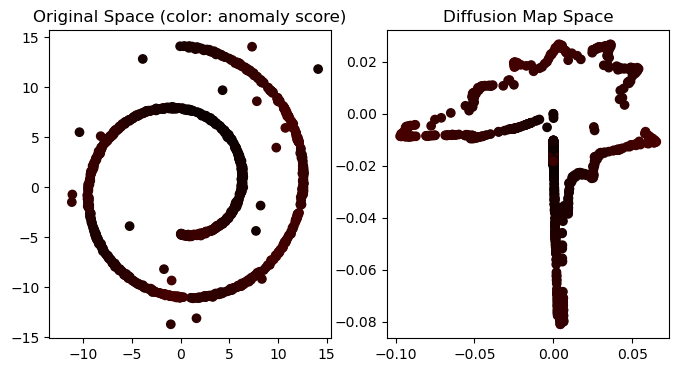

In [2]:
rng = np.random.default_rng(seed=42)
outliers = rng.uniform(low=[-15, -15], high=[15, 15], size=(20, 2))
X_aug = np.vstack([X, outliers])

# 커널 및 확산
K_aug = compute_kernel(X_aug, epsilon)
P_aug = normalize_kernel(K_aug)
coords_aug, _ = diffusion_map(P_aug)

# 평균 좌표 계산
mean_coords = np.mean(coords_aug[:-20], axis=0)  # 정상 포인트 기준

# 이상도 계산
anomaly_score = np.linalg.norm(coords_aug - mean_coords, axis=1)

# 시각화
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_aug[:, 0], X_aug[:, 1], c=anomaly_score, cmap='hot')
plt.title("Original Space (color: anomaly score)")

plt.subplot(1, 2, 2)
plt.scatter(coords_aug[:, 0], coords_aug[:, 1], c=anomaly_score, cmap='hot')
plt.title("Diffusion Map Space")
plt.show()

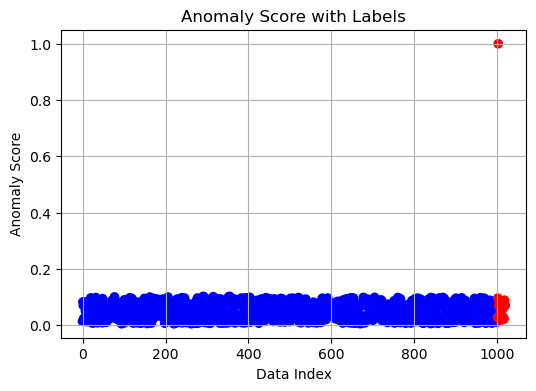

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 라벨 생성
labels = np.array(['normal'] * len(X) + ['abnormal'] * 20)

# 색상 맵핑
colors = np.where(labels == 'normal', 'blue', 'red')

# anomaly score 시각화
plt.figure(figsize=(6, 4))
plt.scatter(range(len(anomaly_score)), anomaly_score, c=colors)
plt.xlabel("Data Index")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Score with Labels")
plt.grid(True)
plt.show()

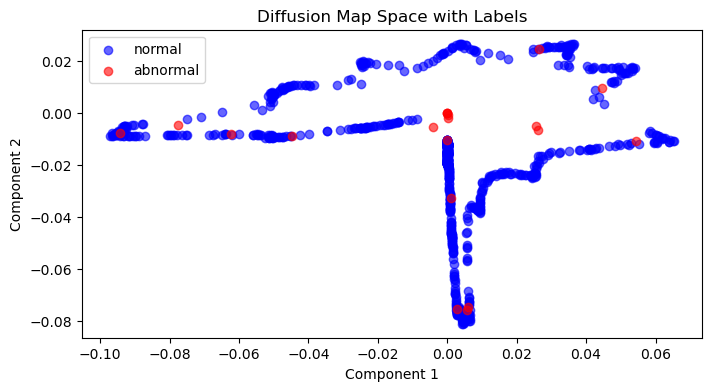

In [8]:
plt.figure(figsize=(8, 4))
for lbl, color in zip(['normal', 'abnormal'], ['blue', 'red']):
    idx = labels == lbl
    plt.scatter(coords_aug[idx, 0], coords_aug[idx, 1], c=color, label=lbl, alpha=0.6)

plt.title("Diffusion Map Space with Labels")
plt.legend()
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

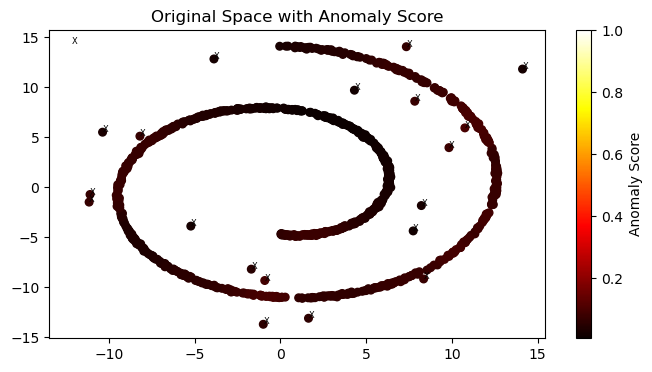

In [9]:
plt.figure(figsize=(8, 4))
plt.scatter(X_aug[:, 0], X_aug[:, 1], c=anomaly_score, cmap='hot', s=30)
for i, lbl in enumerate(labels):
    if lbl == 'abnormal':
        plt.text(X_aug[i, 0], X_aug[i, 1], 'X', color='black', fontsize=6)
plt.title("Original Space with Anomaly Score")
plt.colorbar(label='Anomaly Score')
plt.show()

In [4]:
from scipy.spatial.distance import pdist, squareform

# 확산 거리
diff_dist = squareform(pdist(coords_aug))  # 유클리드 in diffusion coords

# 원래 거리
orig_dist = squareform(pdist(X_aug))

# 비교: 두 거리 간 상관관계
from scipy.stats import spearmanr
corr, _ = spearmanr(orig_dist.flatten(), diff_dist.flatten())
print(f"Spearman correlation between original and diffusion distance: {corr:.4f}")

Spearman correlation between original and diffusion distance: 0.5331


In [5]:
def nystrom_extension(x_new, X_train, psi, lambdas, epsilon):
    # x_new: (1, D) or (D,)
    x_new = np.atleast_2d(x_new)
    
    # Step 1: compute kernel between x_new and X_train
    sq_dists = np.sum((x_new[:, None, :] - X_train[None, :, :])**2, axis=2)
    K = np.exp(-sq_dists / epsilon)  # shape: (1, N)

    # Step 2: normalize to get transition probabilities
    P = K / np.sum(K, axis=1, keepdims=True)  # shape: (1, N)

    # Step 3: project onto eigenvectors
    coords_new = (P @ psi) * lambdas  # shape: (1, m)
    return coords_new

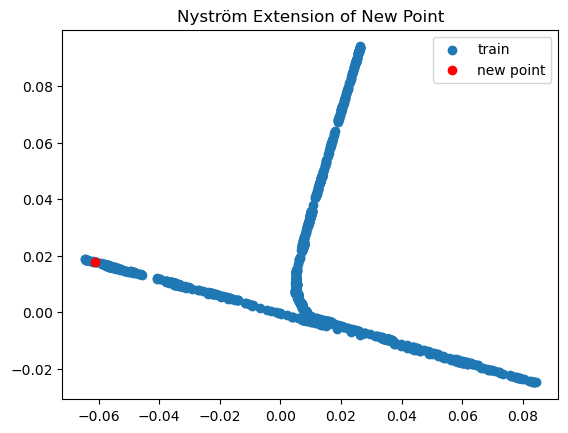

In [6]:
X_train = X
K = compute_kernel(X_train, epsilon)
P = normalize_kernel(K)
psi_all, lambdas_all = diffusion_map(P, n_components=5)

# 새로운 포인트
x_new = np.array([[15.0, 5.0]])  # 명백한 outlier

# 임베딩
coord_new = nystrom_extension(x_new, X_train, psi_all, lambdas_all, epsilon)

# 기존과 함께 시각화
plt.scatter(psi_all[:, 0], psi_all[:, 1], label='train')
plt.scatter(coord_new[:, 0], coord_new[:, 1], color='red', label='new point')
plt.legend()
plt.title("Nyström Extension of New Point")
plt.show()